# **Practice 21 - Data Visualization - Best Practices and More ggplot2**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [1]:
# install packages
install.packages("dslabs")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# load libraries
library(dslabs)
library(ggplot2)

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

<font color=red>Task 1.1</font>

We will be working with the `gapminder` dataset from the `dslabs` package.

* Show the first few lines of the `gapminder` dataset

In [3]:
head(gapminder)

,country,year,infant_mortality,life_expectancy,fertility,population,gdp,continent,region
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,Albania,1960,115.40,62.87,6.19,1636054,NA,Europe,Southern Europe
2,Algeria,1960,148.20,47.50,7.65,11124892,13828152297,Africa,Northern Africa
3,Angola,1960,208.00,35.98,7.32,5270844,NA,Africa,Middle Africa
4,Antigua and Barbuda,1960,NA,62.97,4.43,54681,NA,Americas,Caribbean
5,Argentina,1960,59.87,65.39,3.11,20619075,108322326649,Americas,South America
6,Armenia,1960,NA,66.86,4.55,1867396,NA,Asia,Western Asia


<br>

<font color=red>Task 1.2</font>

* Use the `str()` function to view attributes of the `gapminder` data frame

In [4]:
str(gapminder)

'data.frame':	10545 obs. of  9 variables:
 $ country         : Factor w/ 185 levels "Albania","Algeria",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ year            : int  1960 1960 1960 1960 1960 1960 1960 1960 1960 1960 ...
 $ infant_mortality: num  115.4 148.2 208 NA 59.9 ...
 $ life_expectancy : num  62.9 47.5 36 63 65.4 ...
 $ fertility       : num  6.19 7.65 7.32 4.43 3.11 4.55 4.82 3.45 2.7 5.57 ...
 $ population      : num  1636054 11124892 5270844 54681 20619075 ...
 $ gdp             : num  NA 1.38e+10 NA NA 1.08e+11 ...
 $ continent       : Factor w/ 5 levels "Africa","Americas",..: 4 1 1 2 2 3 2 5 4 3 ...
 $ region          : Factor w/ 22 levels "Australia and New Zealand",..: 19 11 10 2 15 21 2 1 22 21 ...


<br>

<font color=red>Task 1.3</font>

* Run the script `?gapminder` to view the documentation of the `gapminder` data frame.

In [5]:
?gapminder

<br>

<font color=red>Task 1.4</font>

* Subset the `gapminder` dataset to only include the years `1970`, `1990`, and `2010`

* Store the result as a new data frame called `gapminder3`

* Use `unique()` to show the unique years in `gapminder3` to verify your work

In [6]:
# subset original gapminder data frame
gapminder3 <- gapminder[gapminder$year %in% c(1970, 1990, 2010), ]

# show unique years
unique(gapminder3$year)

[1] 1970 1990 2010

In [8]:
nrow(gapminder3)

[1] 441

<br>

<font color=red>Task 1.5</font>

* Run the script below to remove missing values (`NA`) from the data frame

  `gapminder3 <- na.omit(gapminder3)`

In [7]:
gapminder3 <- na.omit(gapminder3)

<br>

<br>

<br>

---

####<font color=red>Task 2</font>


Gross domestic product (GDP) is an economic indicator quantifying the size of an economy. Countries with higher GDP typically have stronger economies. Let's analyze this metric.

<font color=red>Task 2.1</font>

* Use `ggplot()` to plot a histogram of `gdp` for the `gapminder3` data frame.
  * Be sure to include a title and axes labels using the `labs()` layer

* What are your observations about the shape of the distribution of `gdp`?

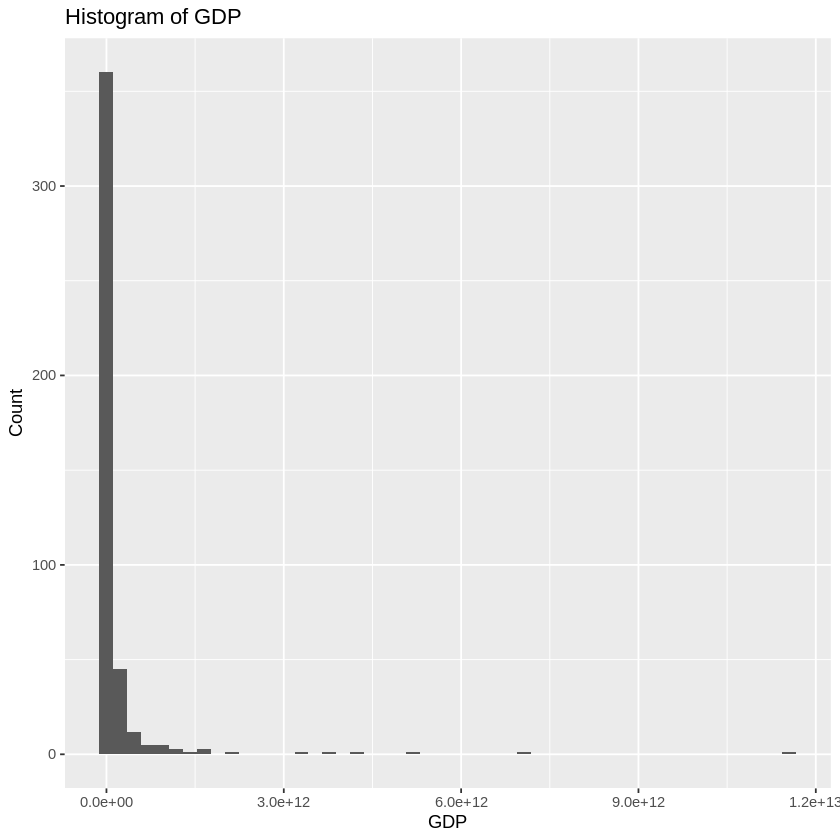

In [9]:
ggplot(data = gapminder3, aes(x = gdp)) +
  geom_histogram(bins = 50) +
  labs(title = "Histogram of GDP",
      x = "GDP",
      y = "Count")

Observations: The `gdp` variable is heavily right skewed and could benefit from a log transfermation for better visualization.

<br>

<font color=red>Task 2.2</font>

* Apply a log transformation to the `gdp` variable that will make the data easier to visualize.

* Store the transformed `gdp` variable as another variable `log_gdp` in the `gapminder3` data frame

* Plot a histogram of `log_gdp`

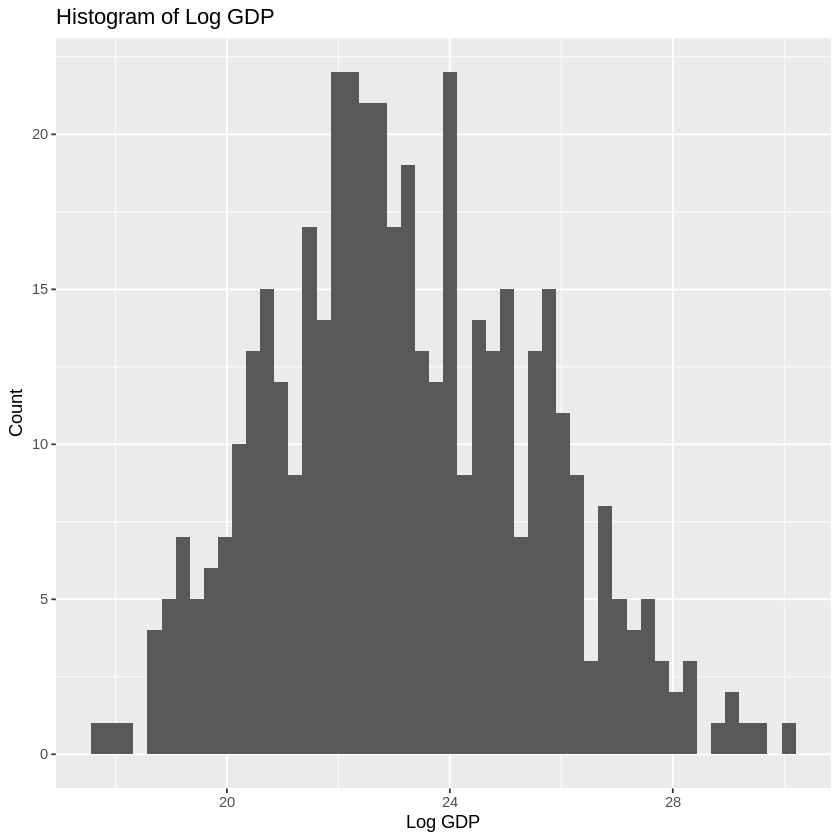

In [10]:
# log transformation
gapminder3$log_gdp <- log(gapminder3$gdp)

# plot the histogram of log gdp
ggplot(data = gapminder3, aes(x = log_gdp)) +
  geom_histogram(bins = 50) +
  labs(title = "Histogram of Log GDP",
      x = "Log GDP",
      y = "Count")

<br>

<font color=red>Task 2.3</font>

* Plot the histogram from Task 2.2 with its continuous density function (density should now be on the y-axis)

* What are your observations about the distribution of log GDP?
  * Is the distribution skewed?
  * Is the distribution multimodal?
  * etc.

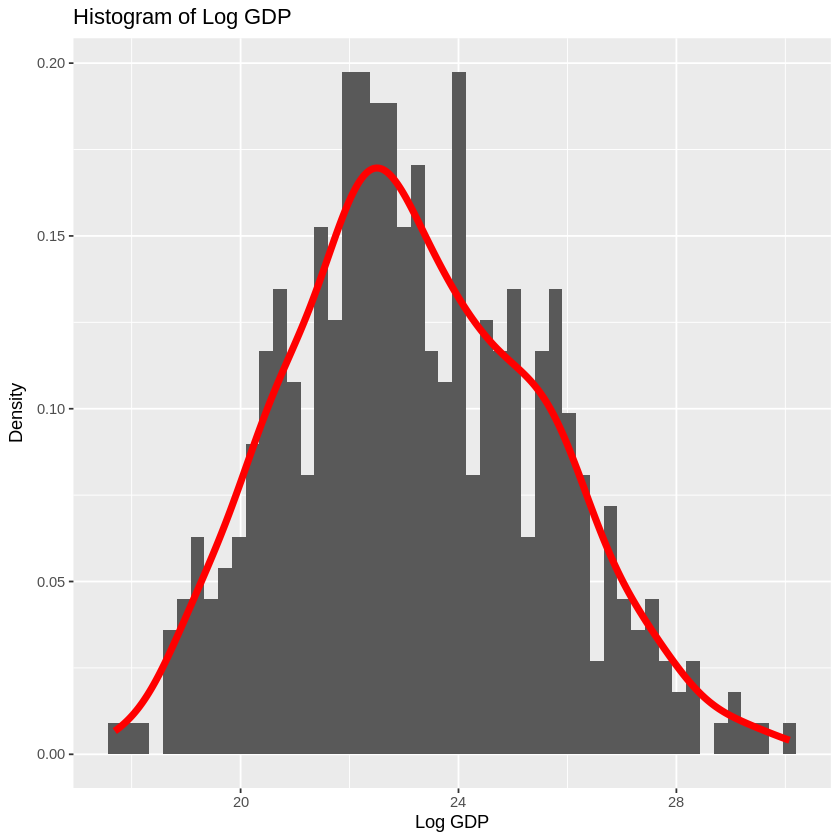

In [14]:
ggplot(data = gapminder3, aes(x = log_gdp, y = after_stat(density))) +
  geom_histogram(bins = 50) +
  geom_density(color = "red", linewidth = 2) +
  labs(title = "Histogram of Log GDP",
  x = "Log GDP",
  y = "Density")

Observations: The distributions are more symmetrical now with slight right skewness. The continuous density suggets that there may be two modes.

<br>

<font color=red>Task 2.4</font>

* Plot the histogram and density from Task 2.4 but also include the `year` variable in a `facet_wrap()` layer

  * Be sure to specify `nrow = 3` in the `facet_wrap()` layer

* What are your observations of the distribution of log GDP over the three years?

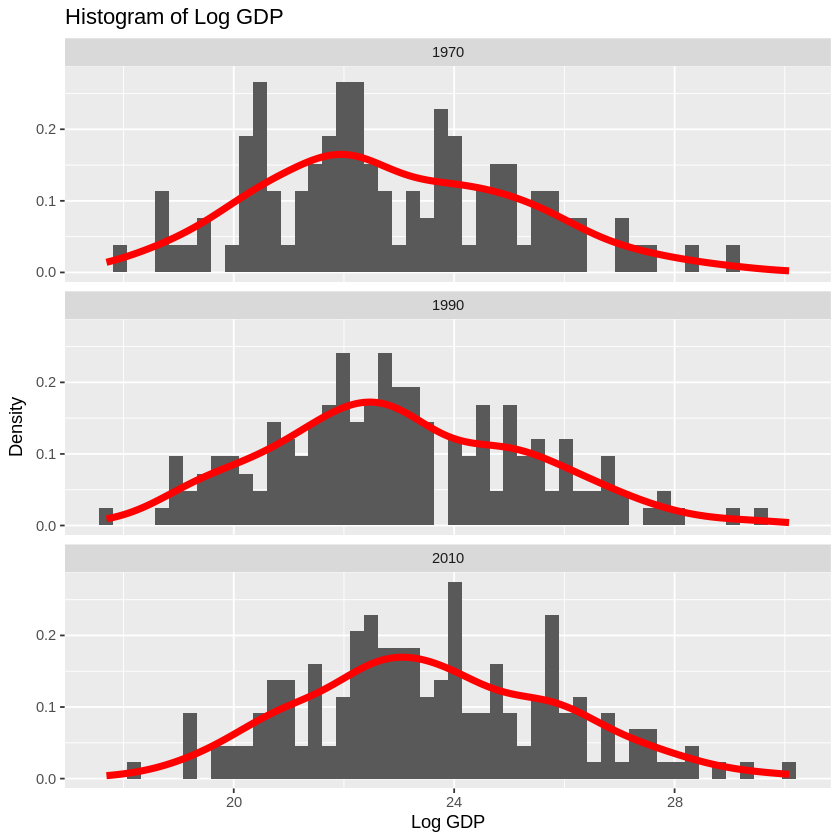

In [15]:
ggplot(data = gapminder3, aes(x = log_gdp, y = after_stat(density))) +
  geom_histogram(bins = 50) +
  geom_density(color = "red", linewidth = 2) +
  facet_wrap(~year, nrow = 3) +
  labs(title = "Histogram of Log GDP",
  x = "Log GDP",
  y = "Density")

Observations: The distributions of the three log GDP's appear relatively the same. All three are skewed right with a mean of ~23.

<br>

<br>

<br>

---

####<font color=red>Task 3</font>


<font color=red>Task 3.1</font>

* Use `ggplot()` to plot a boxplot with `log_gdp` on the y-axis and `region` on the x-axis from the `gapminder3` data frame

  * You can use the script below to resize your boxplot

    `options(repr.plot.width = 25, repr.plot.height = 8)`

* Label your axes appropriately

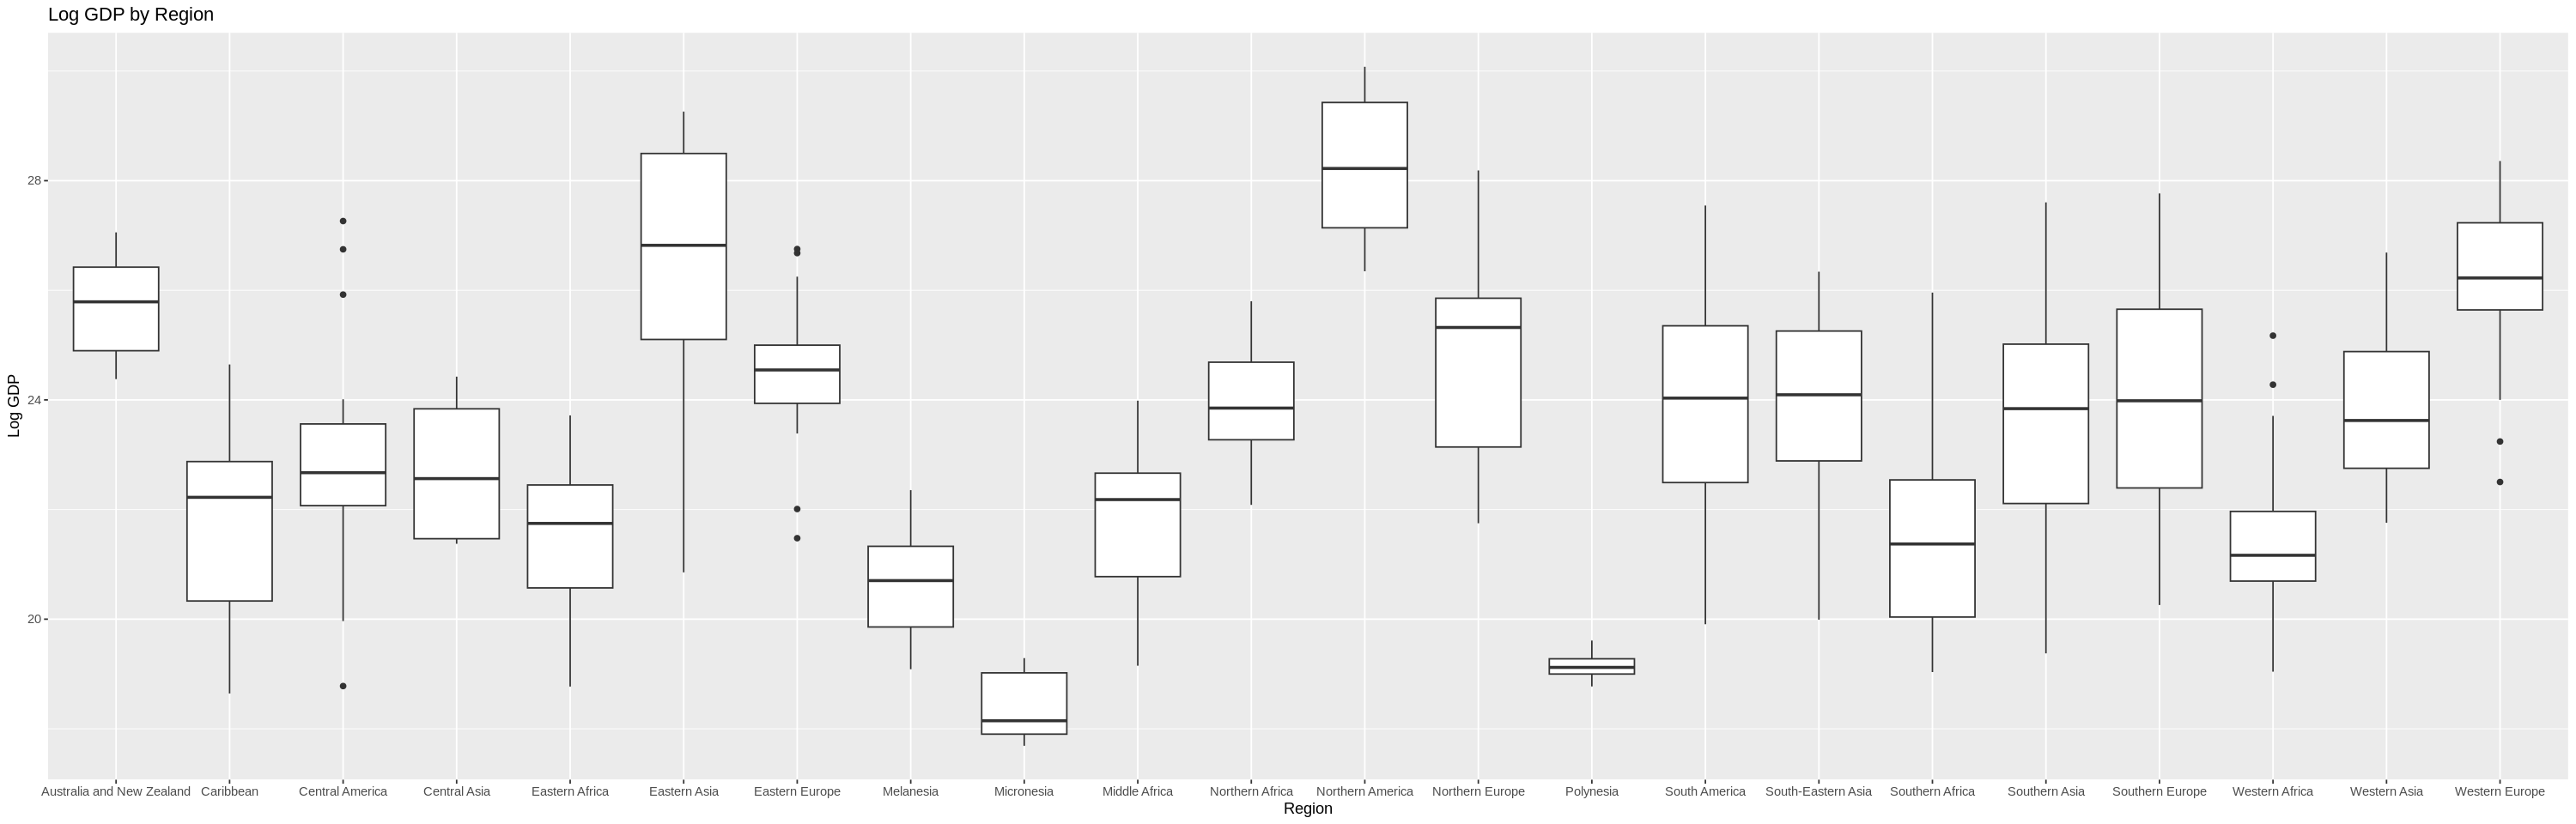

In [17]:
# setting the dimensions for our graphic
options(repr.plot.width = 25, repr.plot.height = 8)

ggplot(data = gapminder3, aes(x = region, y = log_gdp)) +
  geom_boxplot() +
  labs(title = "Log GDP by Region",
  x = "Region",
  y = "Log GDP")

<br>

<font color=red>Task 3.2</font>

* Order the categories in your boxplot from smallest median log GDP to largest median log GDP

    `options(repr.plot.width = 25, repr.plot.height = 8)`

* What are your observations?
  * Which region has the lowest/highest log GDP?
  * Which region has the highest variability in log GDP?
  * Compare some regions
  * etc.

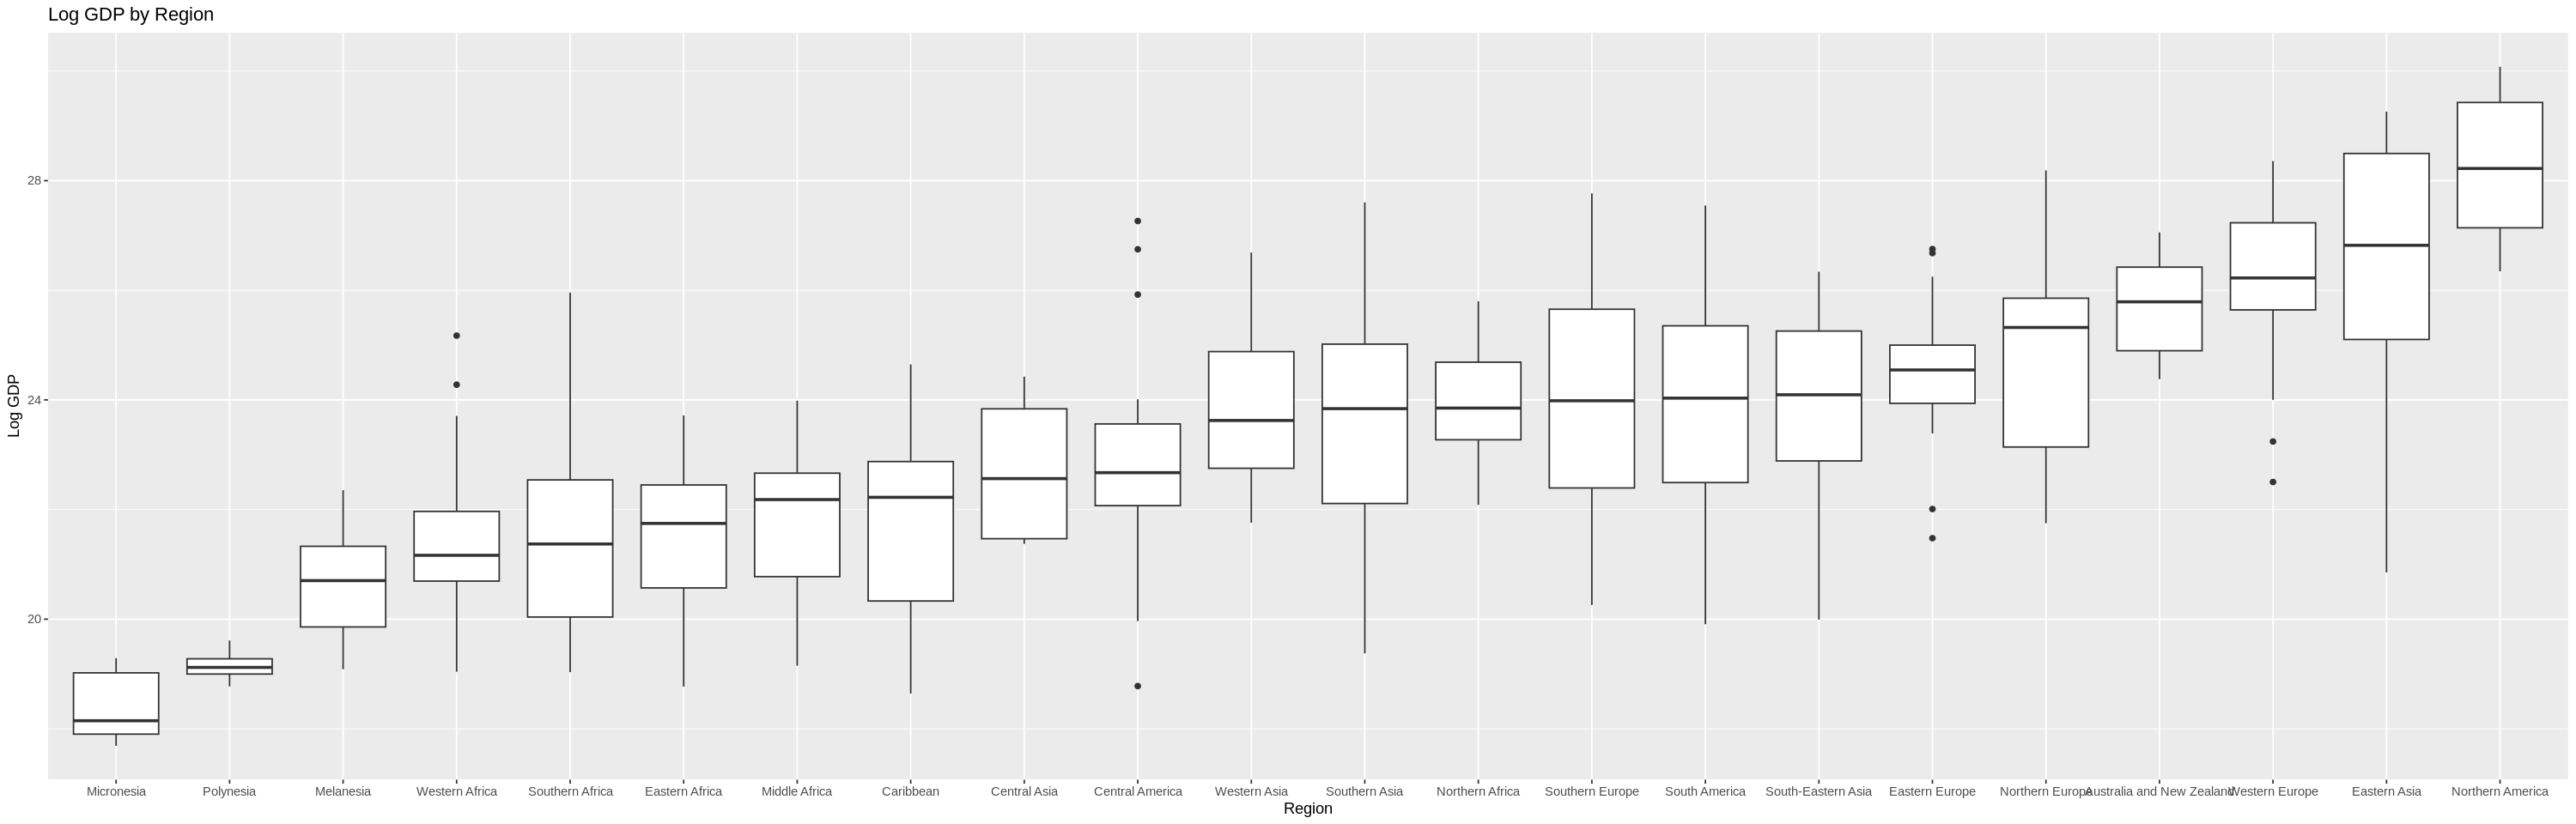

In [18]:
# setting the dimensions for our graphic
options(repr.plot.width = 25, repr.plot.height = 8)

ggplot(data = gapminder3, aes(x = reorder(region, log_gdp, FUN = median), y = log_gdp)) +
  geom_boxplot() +
  labs(title = "Log GDP by Region",
  x = "Region",
  y = "Log GDP")

Observations: The region with the highest log GDP is Northern America. The region with the lowest log GDP is Micronesia. The region with the highest variability in log GDP appears to be regions in Asia and South America.

<br>

<font color=red>Task 3.3</font>

* Plot your boxplot from Task 3.3 with a jitter geometry layer

  * Use the appropriate `width` and `alpha` arguments to make the visualization easier to interpret

* Which regions have very few data points?

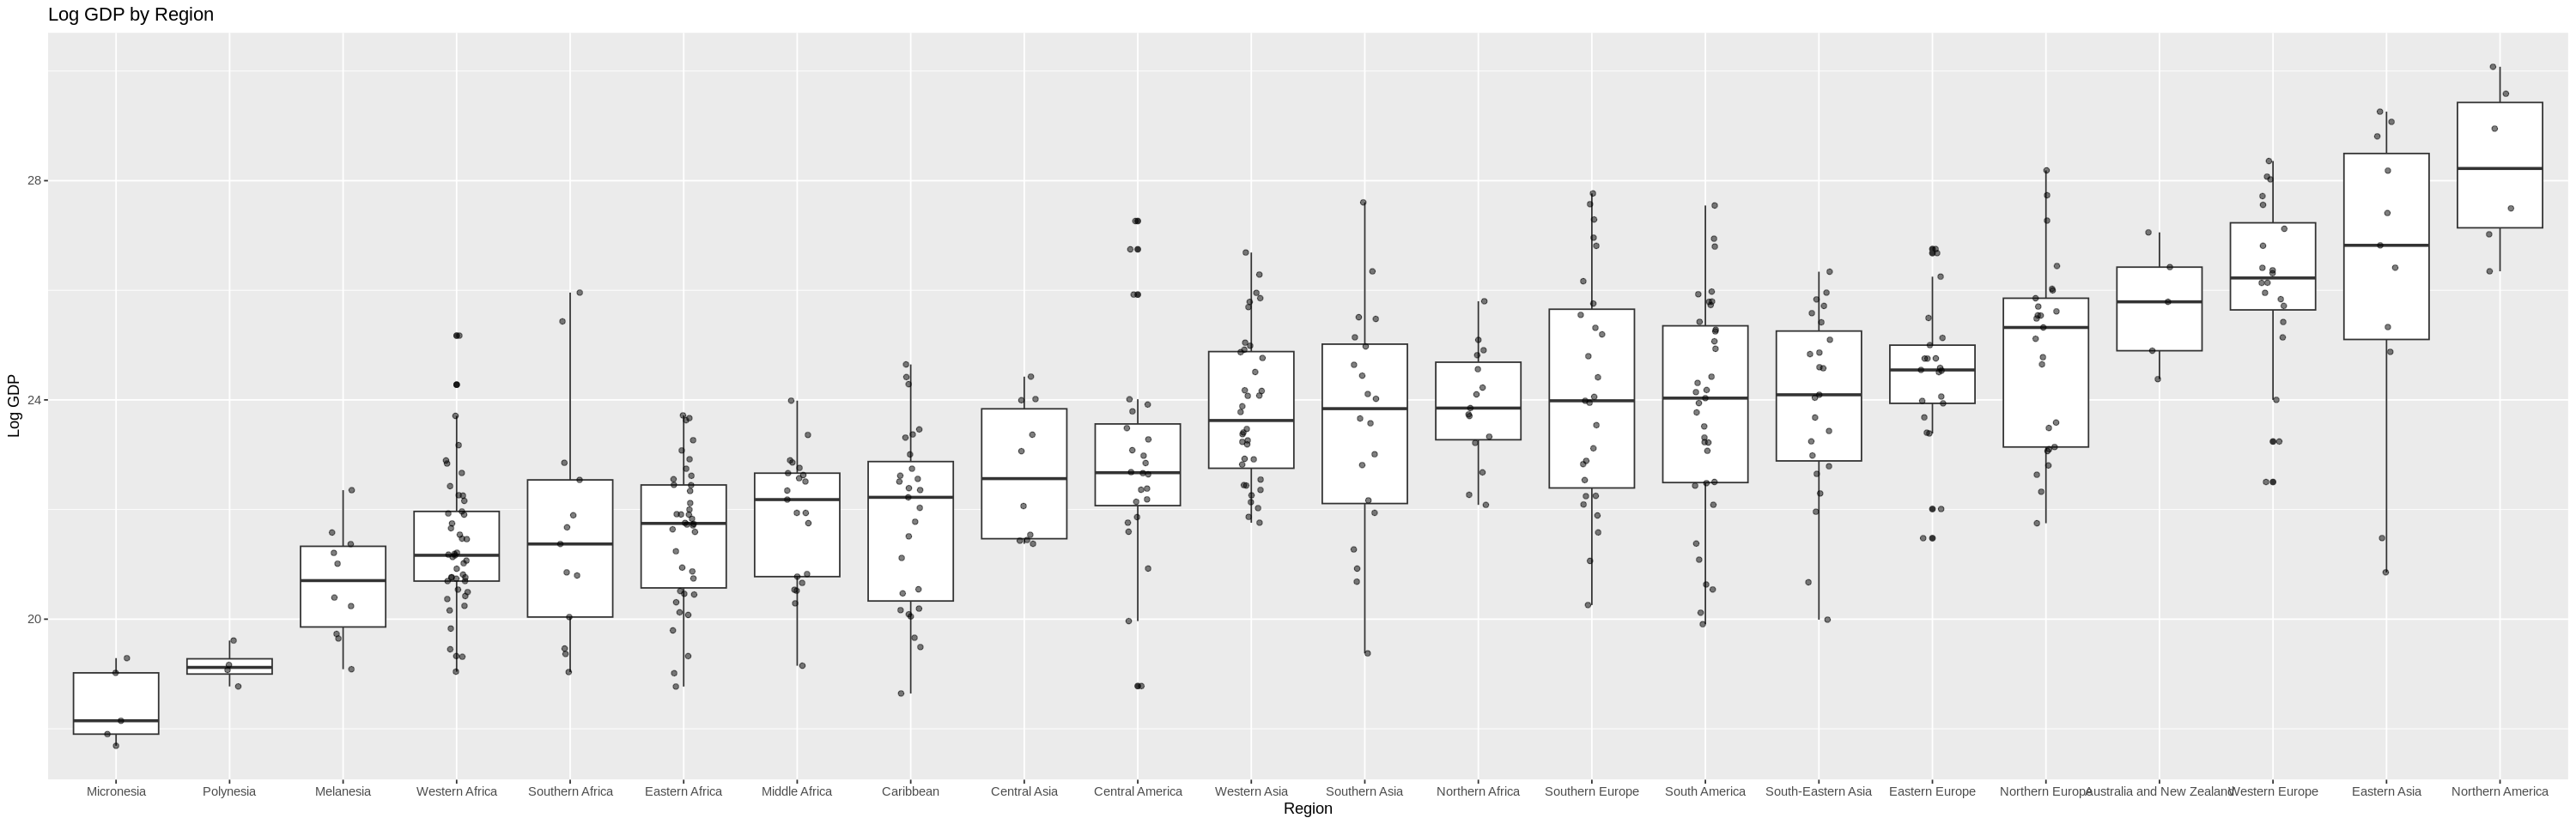

In [19]:
# setting the dimensions for our graphic
options(repr.plot.width = 25, repr.plot.height = 8)

ggplot(data = gapminder3, aes(x = reorder(region, log_gdp, FUN = median), y = log_gdp)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) +
  labs(title = "Log GDP by Region",
  x = "Region",
  y = "Log GDP")

Micronesia, Polynesia, Australia, and New Zealand have very few data points.

<br>

<font color=red>Task 3.4</font>

* Include `year` as a fill argument to the boxplot from Task 3.2 (no jitter)

  Hint: `year` must be a factor in this case


* What are your observations of log GDP in each region across the three years?

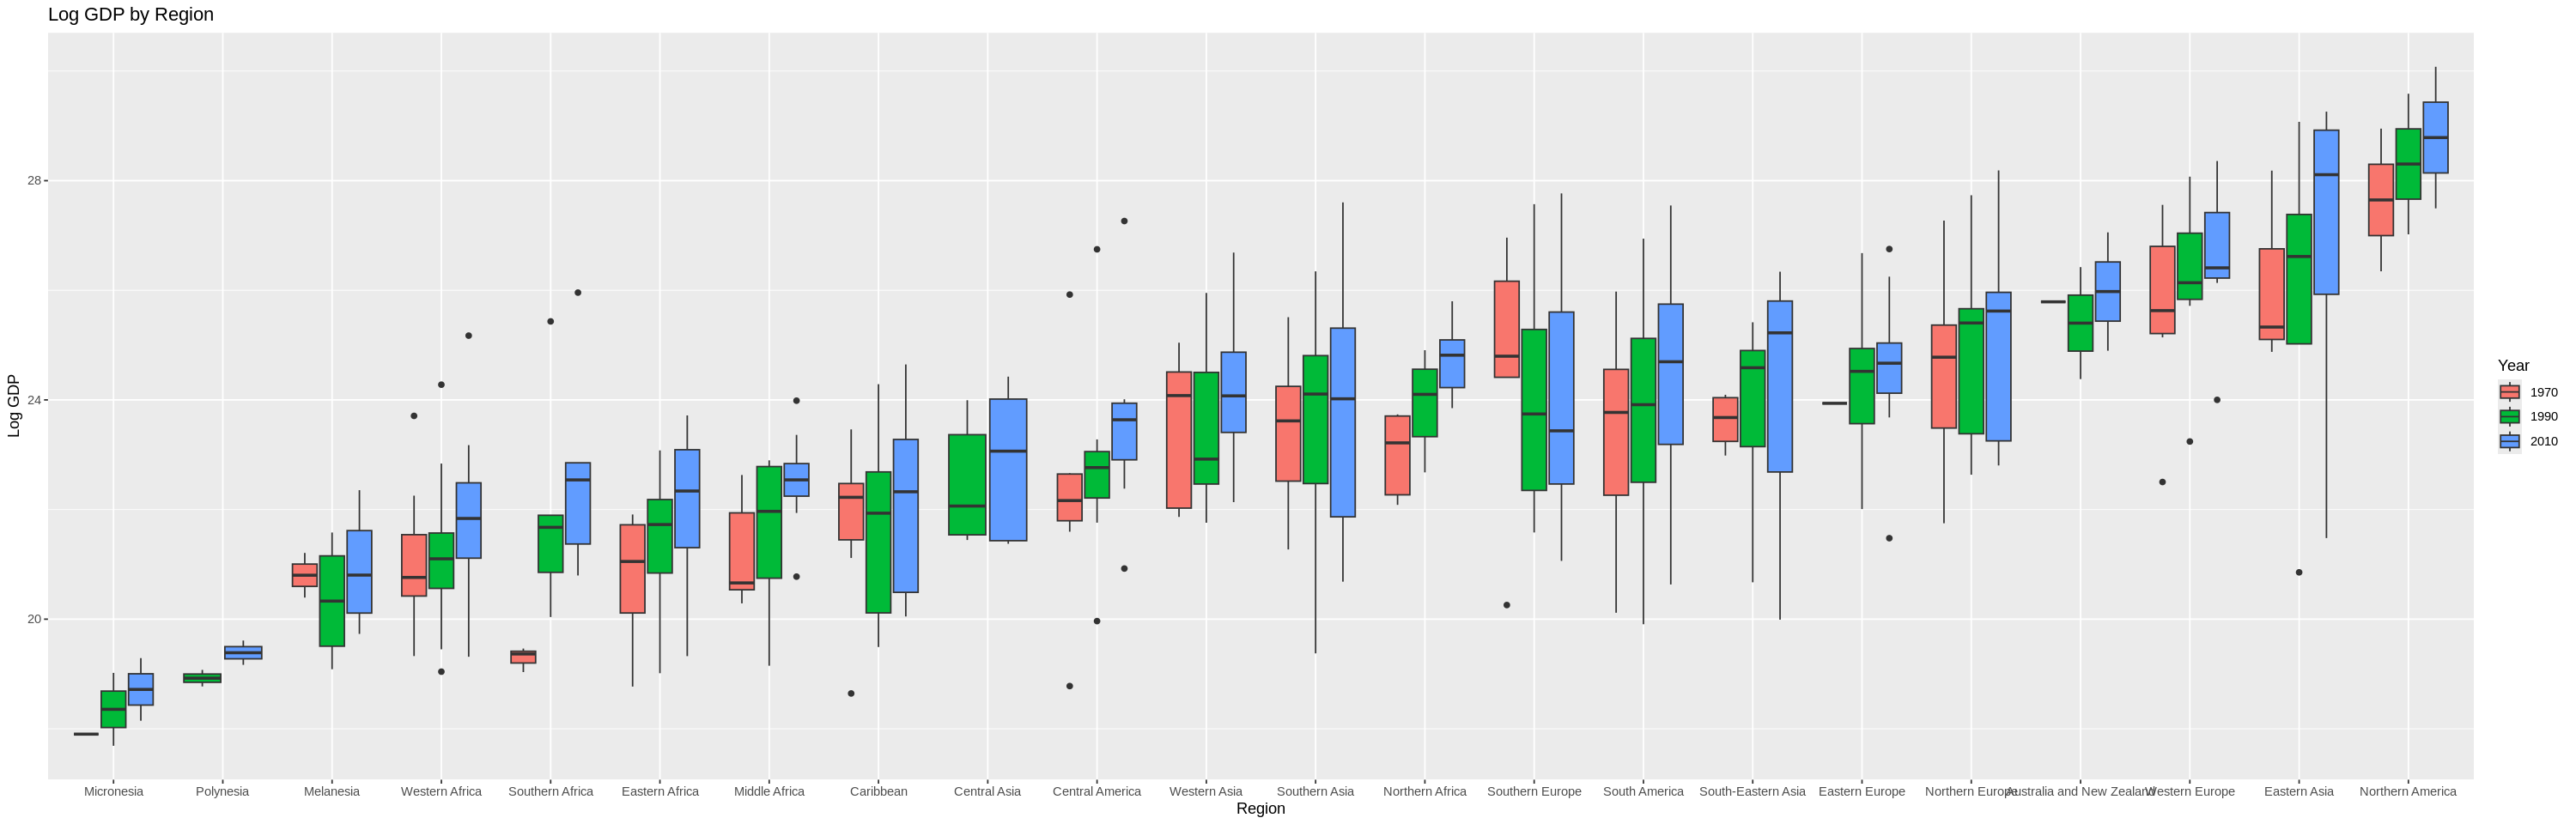

In [21]:
# setting the dimensions for our graphic
options(repr.plot.width = 25, repr.plot.height = 8)

ggplot(data = gapminder3, aes(x = reorder(region, log_gdp, FUN = median),
                                          y = log_gdp,
                                          fill = factor(year))) +
  geom_boxplot() +
  labs(title = "Log GDP by Region",
  x = "Region",
  y = "Log GDP",
  fill = "Year")

Log GDP appears to increase accross most regions of time.

<br>

<font color=red>Task 3.5</font>

* Change the colors of `year` in your boxplot from `Task 3.3` to be colorblind friendly using a `scale_fill_brewer()` layer

* Use the `"Dark2"` palette
    

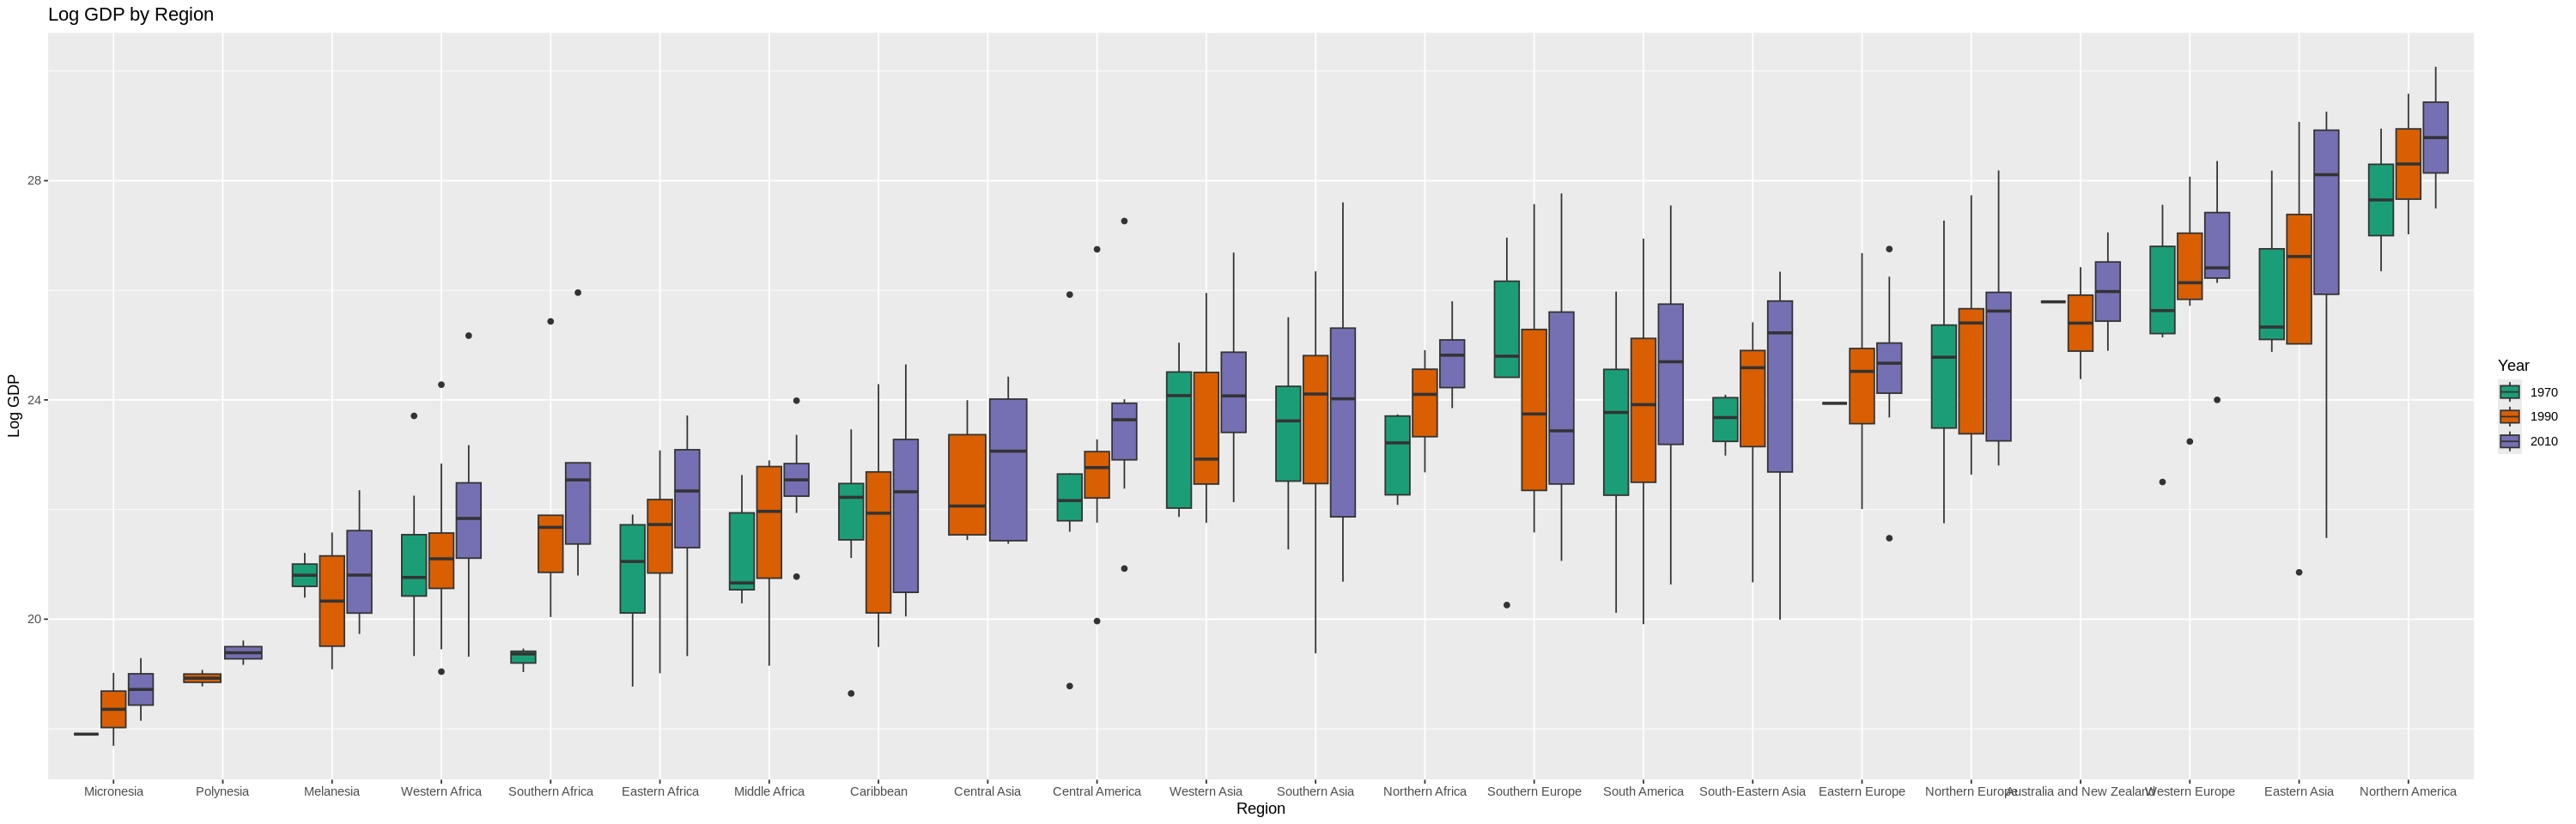

In [23]:
# setting the dimensions for our graphic
options(repr.plot.width = 25, repr.plot.height = 8)

ggplot(data = gapminder3, aes(x = reorder(region, log_gdp, FUN = median),
                                          y = log_gdp,
                                          fill = factor(year))) +
  geom_boxplot() +
  scale_fill_brewer(palette = "Dark2") +
  labs(title = "Log GDP by Region",
  x = "Region",
  y = "Log GDP",
  fill = "Year")

<br>

<br>

<br>

---

####<font color=red>Task 4</font>


<font color=red>Task 4.1</font>

* Use `ggplot()` to plot a scatter plot with `life_expectancy` on the y-axis and `log_gdp` on the x-axis from the `gapminder3` data frame

* What are your observations?

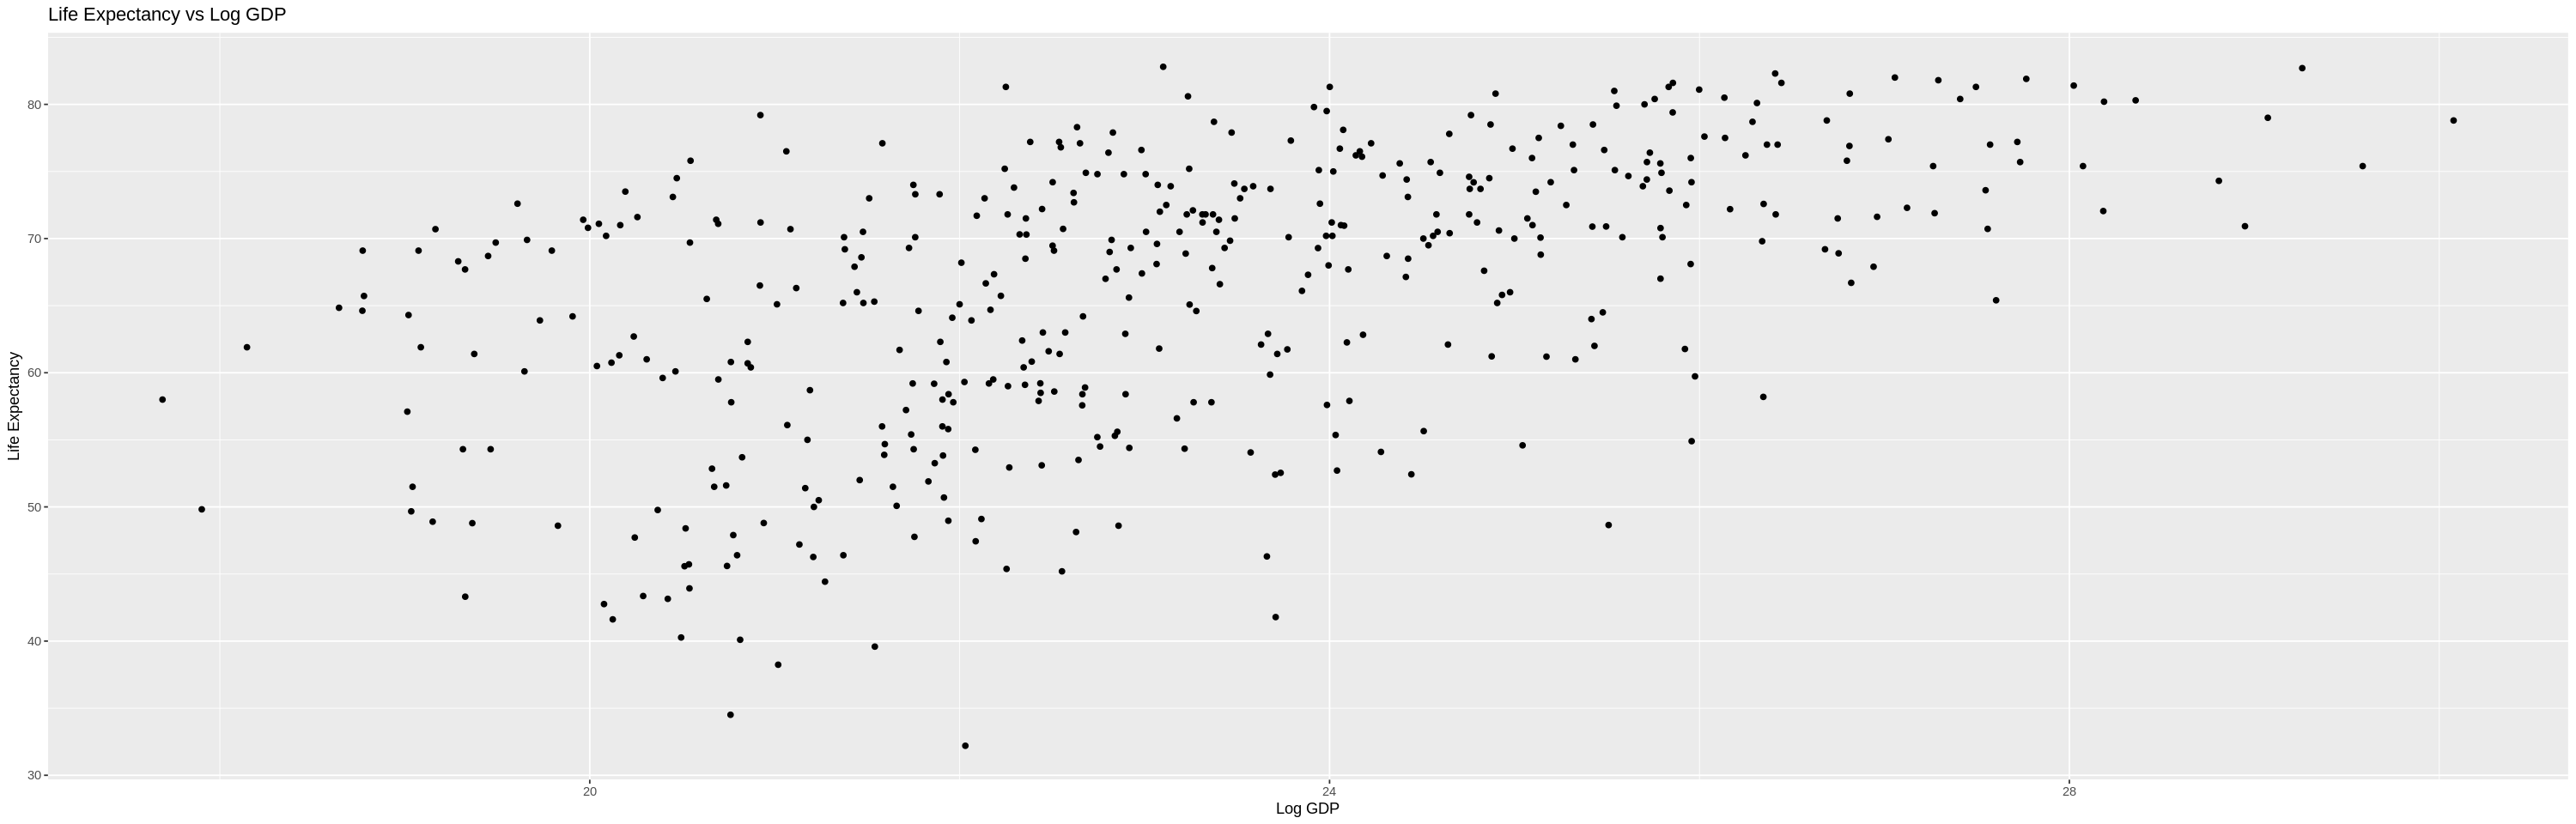

In [24]:
ggplot(data = gapminder3, aes(x = log_gdp, y = life_expectancy)) +
  geom_point() +
  labs(title = "Life Expectancy vs Log GDP",
  x = "Log GDP",
  y = "Life Expectancy")

The scatterplot suggest life expectancy is higher in countries with higher GDP. The trend is logarithmic, where increases in life expectancy decrease as GDP increases.

<br>

<font color=red>Task 4.2</font>

* Plot your scatter plot from Task 4.1 with a color visual dimension for `continent`

* Also, increase the overall size of the points by including a `size = ` argument in the point geometry layer

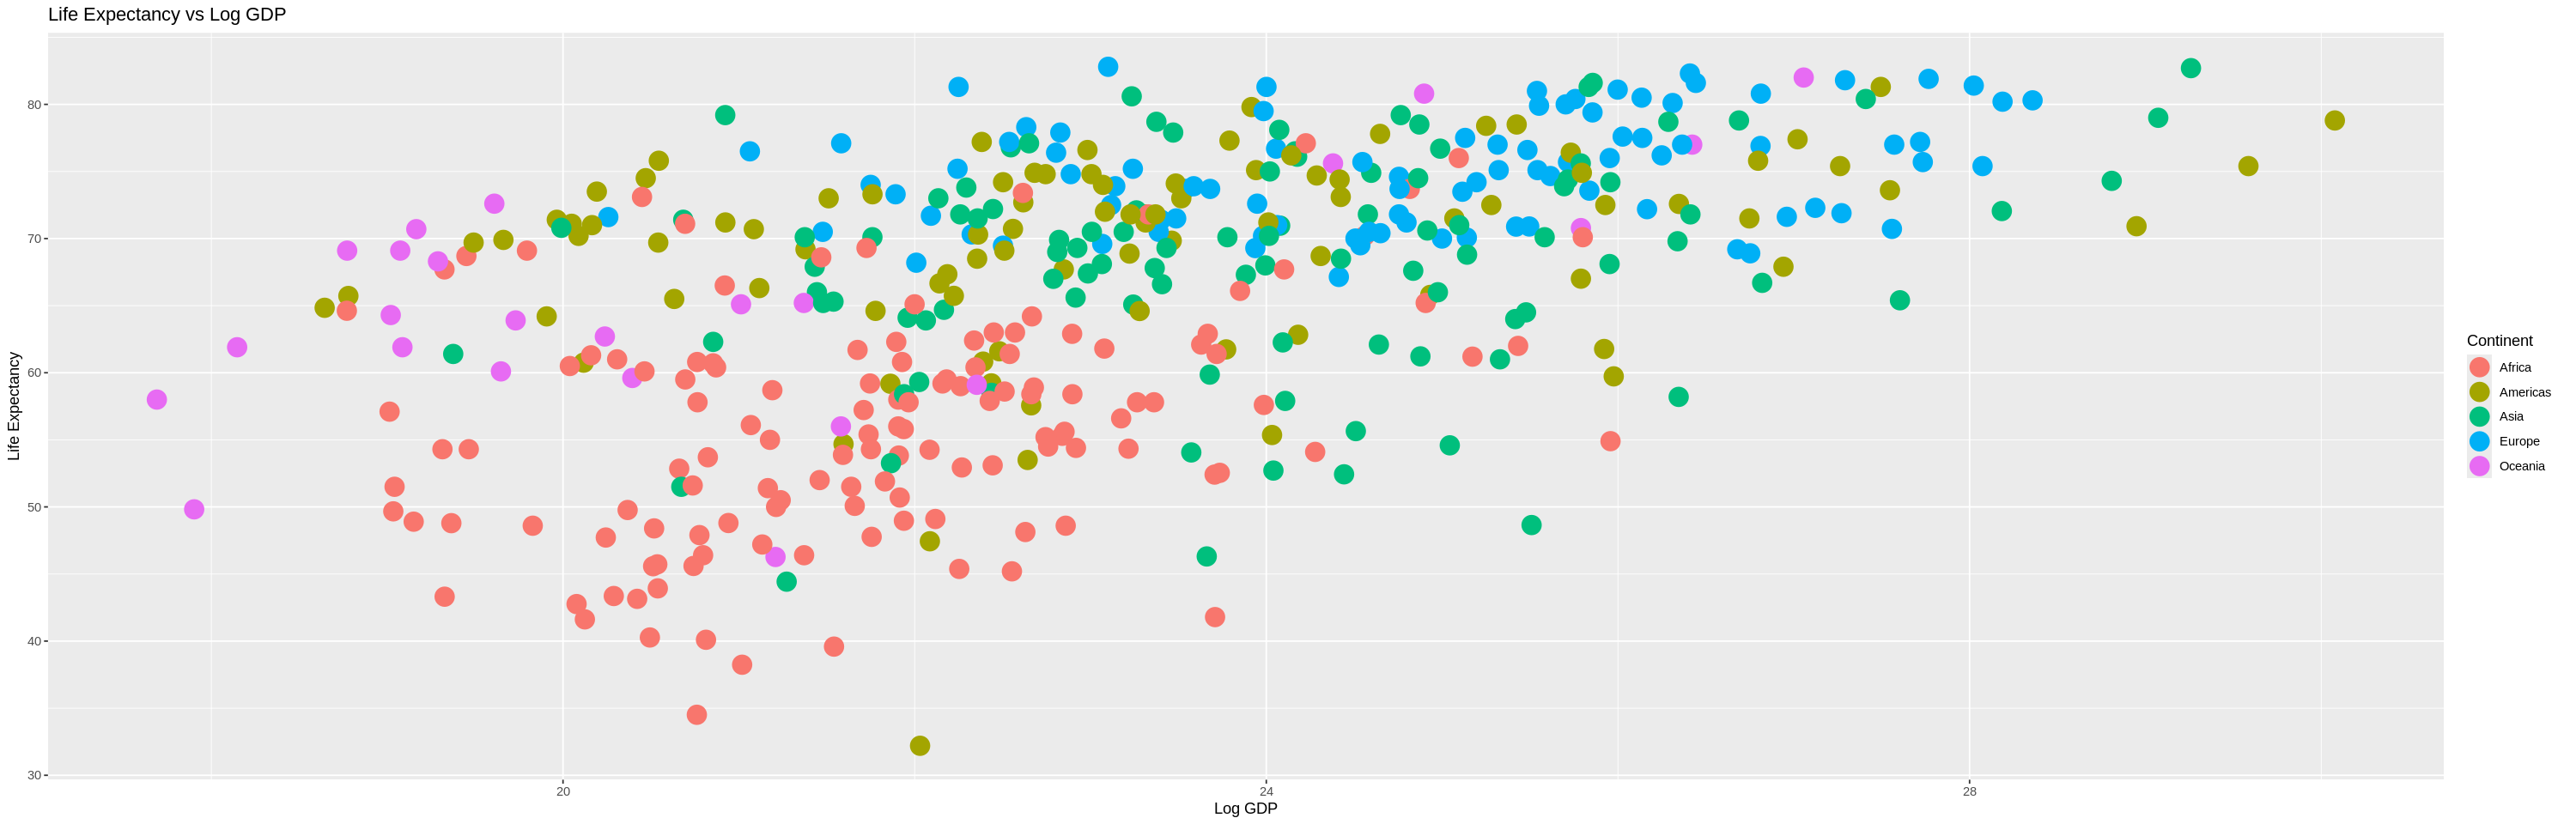

In [28]:
ggplot(data = gapminder3, aes(x = log_gdp,
                              y = life_expectancy,
                              color = continent)) +
  geom_point(size = 6) +
  labs(title = "Life Expectancy vs Log GDP",
  x = "Log GDP",
  y = "Life Expectancy",
  color = "Continent")

<br>

<font color=red>Task 4.3</font>

* Include a `facet_wrap` layer for `year` to your plot from Task 4.2

* What are your observations?
  * Are there changes over time?
  * Does variability change?
  * etc.

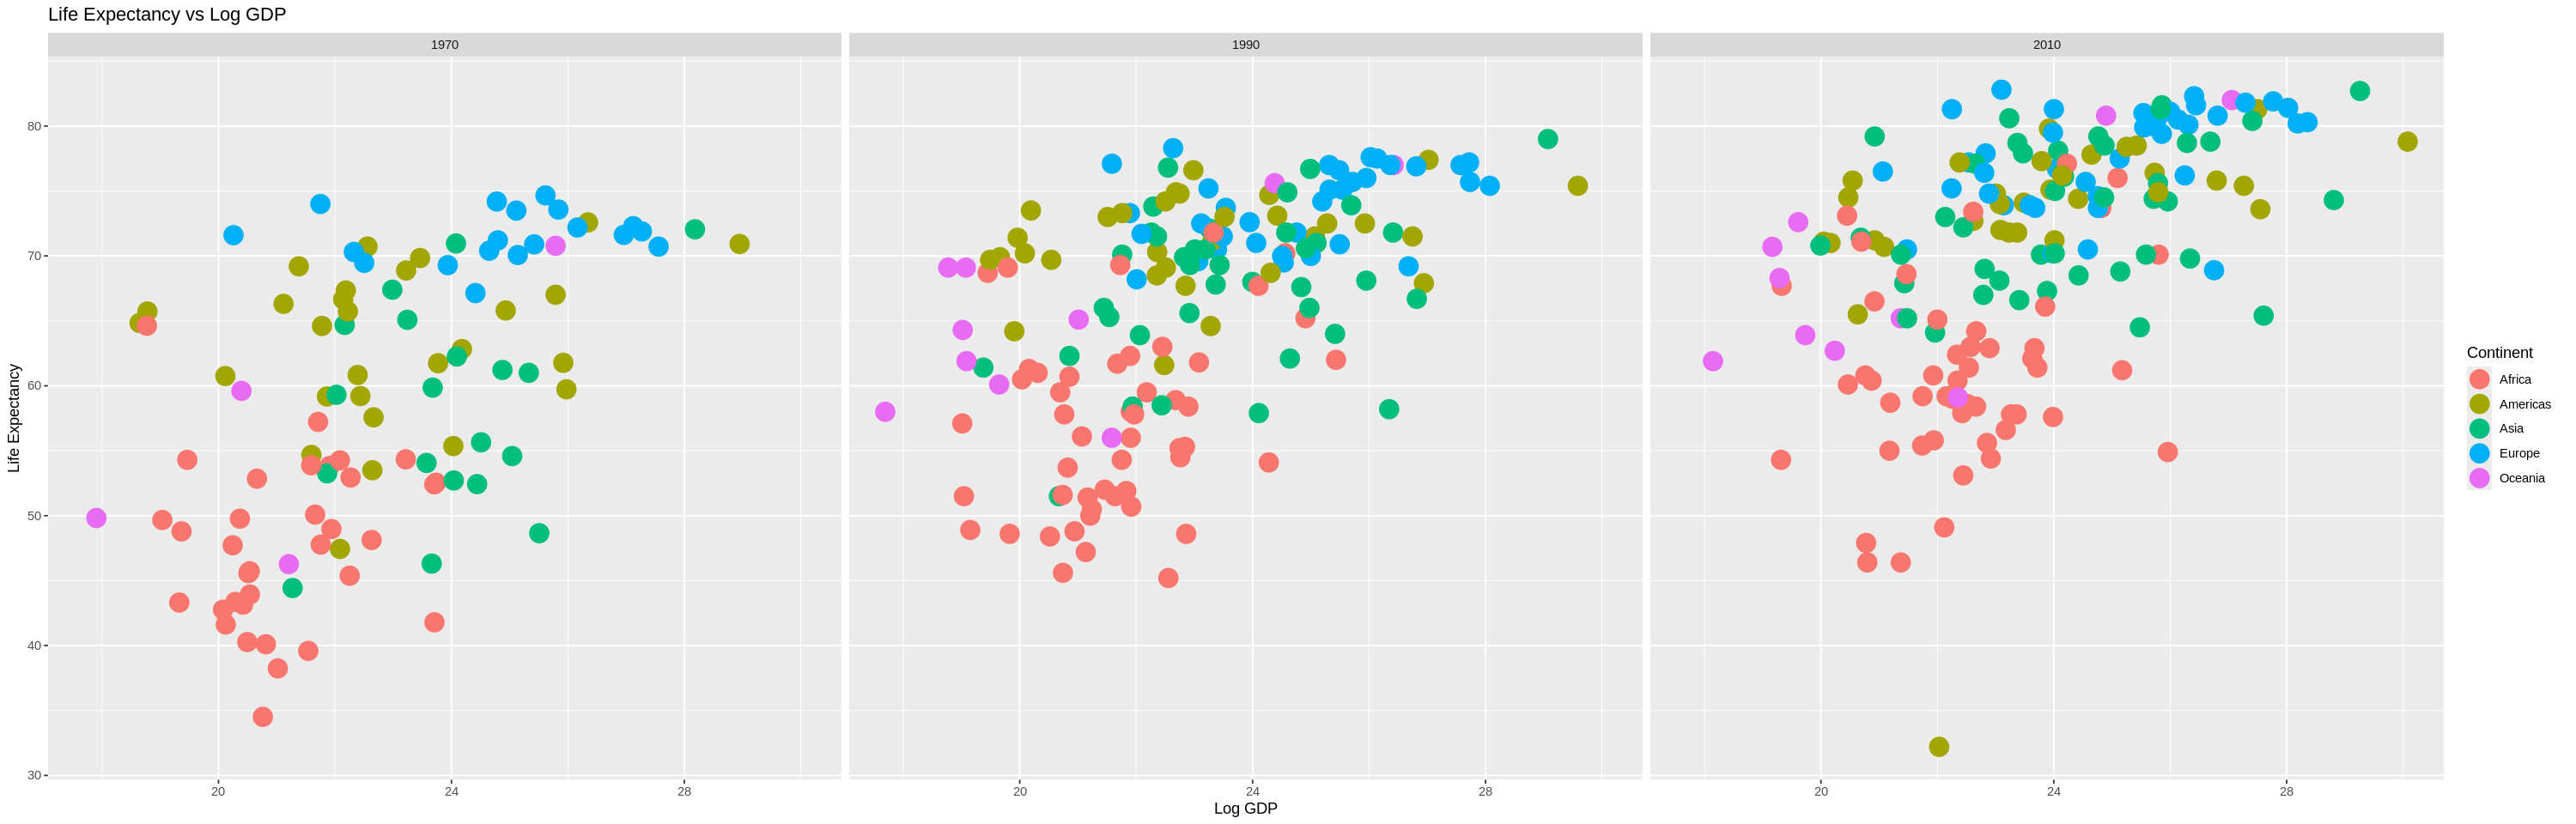

In [30]:
ggplot(data = gapminder3, aes(x = log_gdp,
                              y = life_expectancy,
                              color = continent)) +
  geom_point(size = 6) +
  facet_wrap(~year) +
  labs(title = "Life Expectancy vs Log GDP",
  x = "Log GDP",
  y = "Life Expectancy",
  color = "Continent")

Overall, life expectancy has been increasing over time. Variability in life expectancy appears to be decreasing since the points are more tightly clustered in 2010.

<br>

<font color=red>Task 4.4</font>

* Include log population as a size dimension in your plot from Task 4.3

* Change the colors to be colorblind friendly using `scale_color_brewer()` and the `Dark2` color palette

* What are your observations regarding population size?

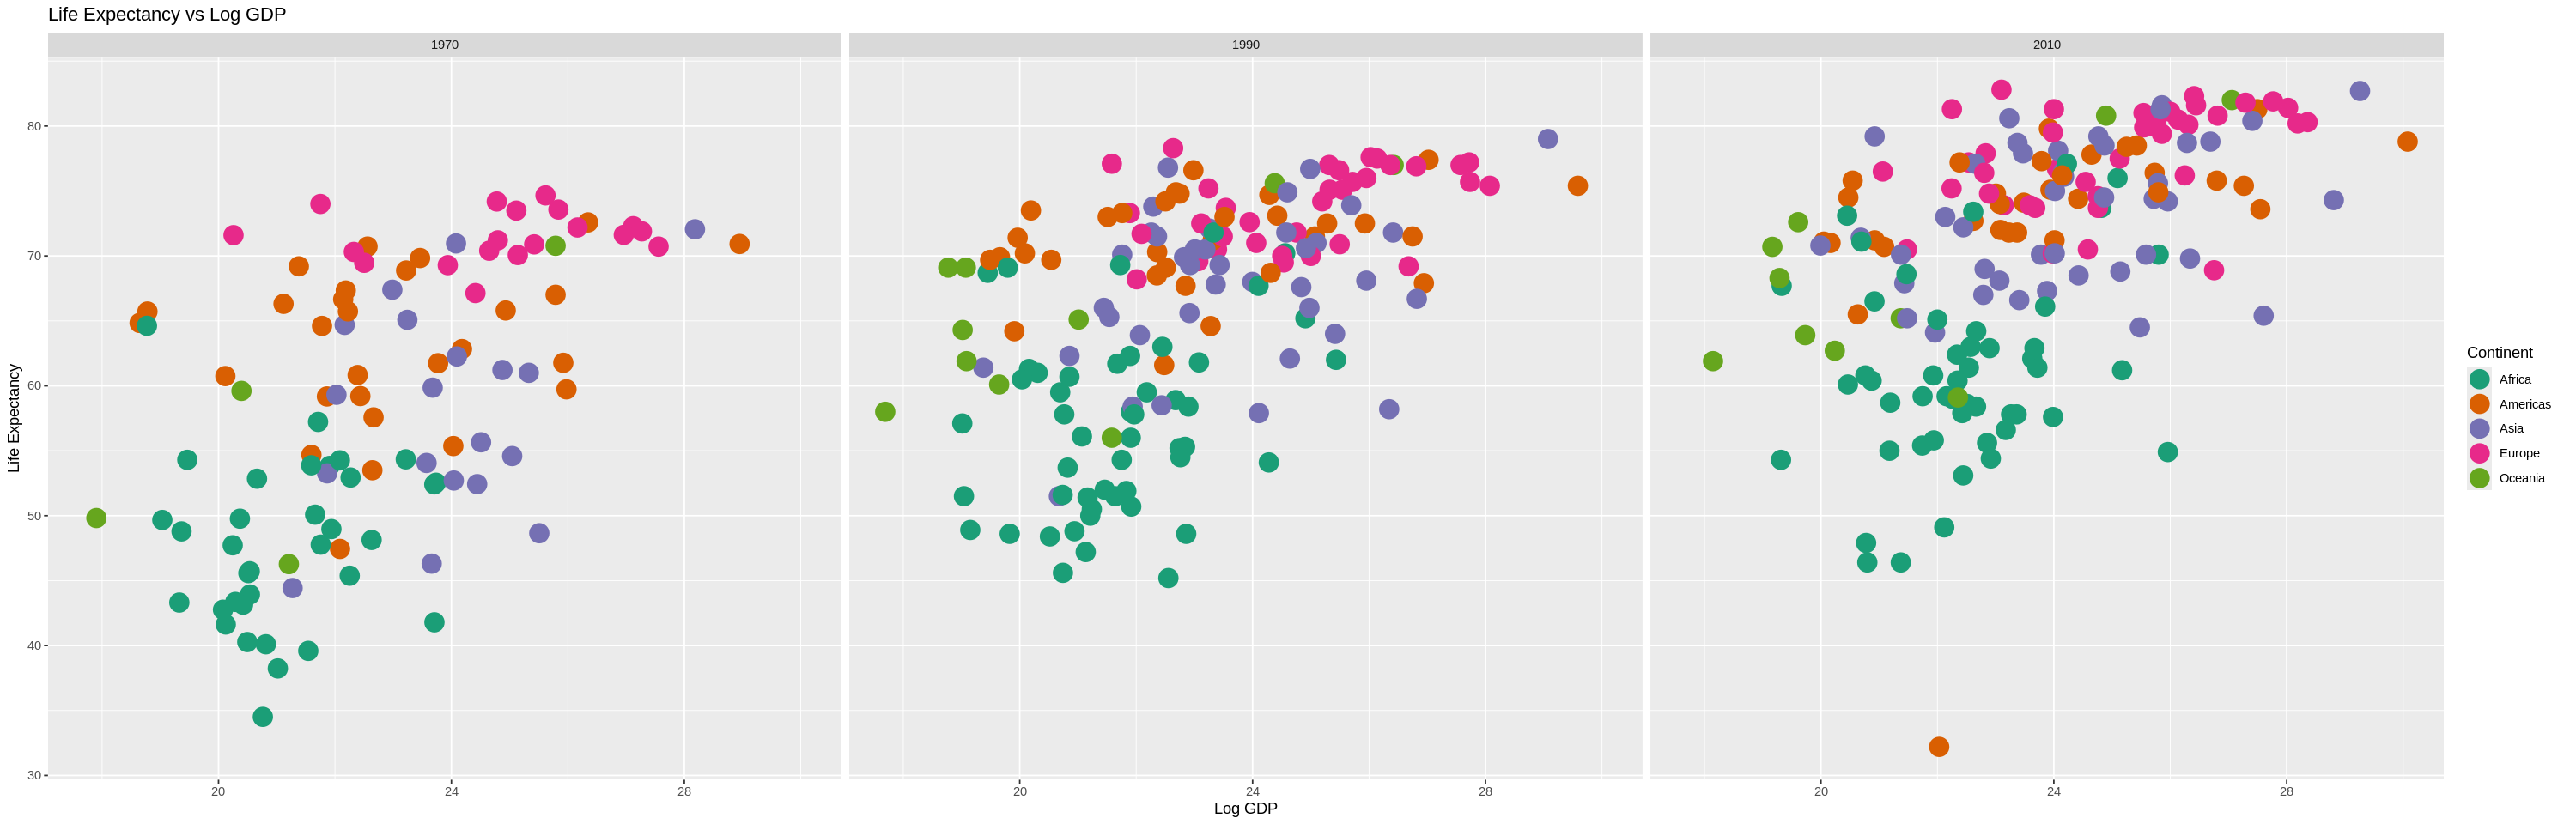

In [34]:
ggplot(data = gapminder3, aes(x = log_gdp,
                              y = life_expectancy,
                              color = continent,
                              size = population)) +
  geom_point(size = 6) +
  facet_wrap(~year) +
  scale_color_brewer(palette = "Dark2") +
  labs(title = "Life Expectancy vs Log GDP",
  x = "Log GDP",
  y = "Life Expectancy",
  color = "Continent")

<br>

<br>

<br>

---

####<font color=red>Task 5</font>


<font color=red>Task 5.1</font>

* Search online for two "bad" data visualizations

* Paste each visualization in a text cell

* In another text cell, explain why these are poor data visualizations

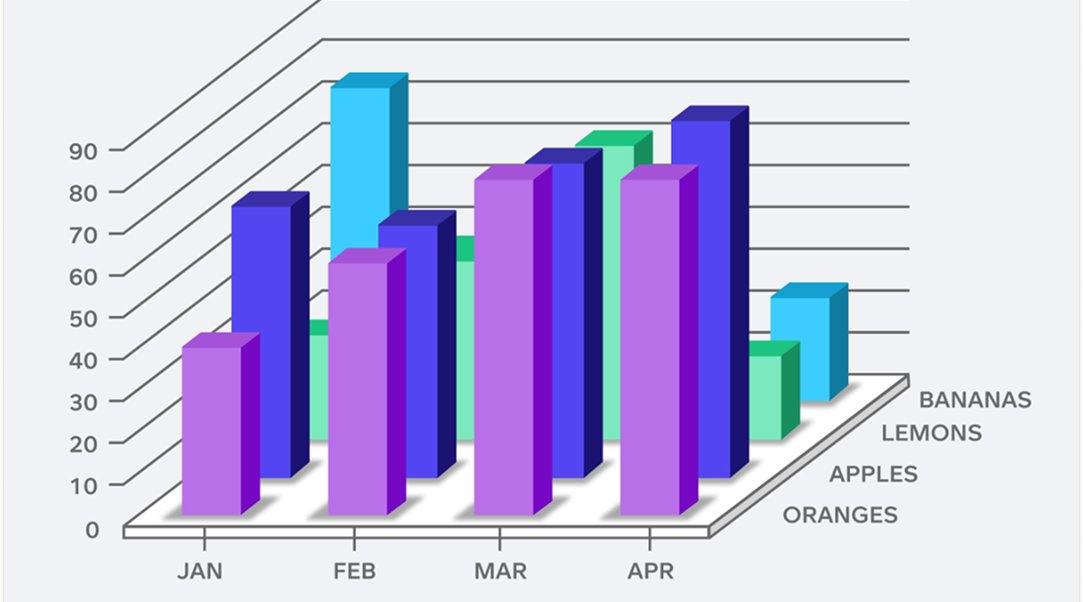




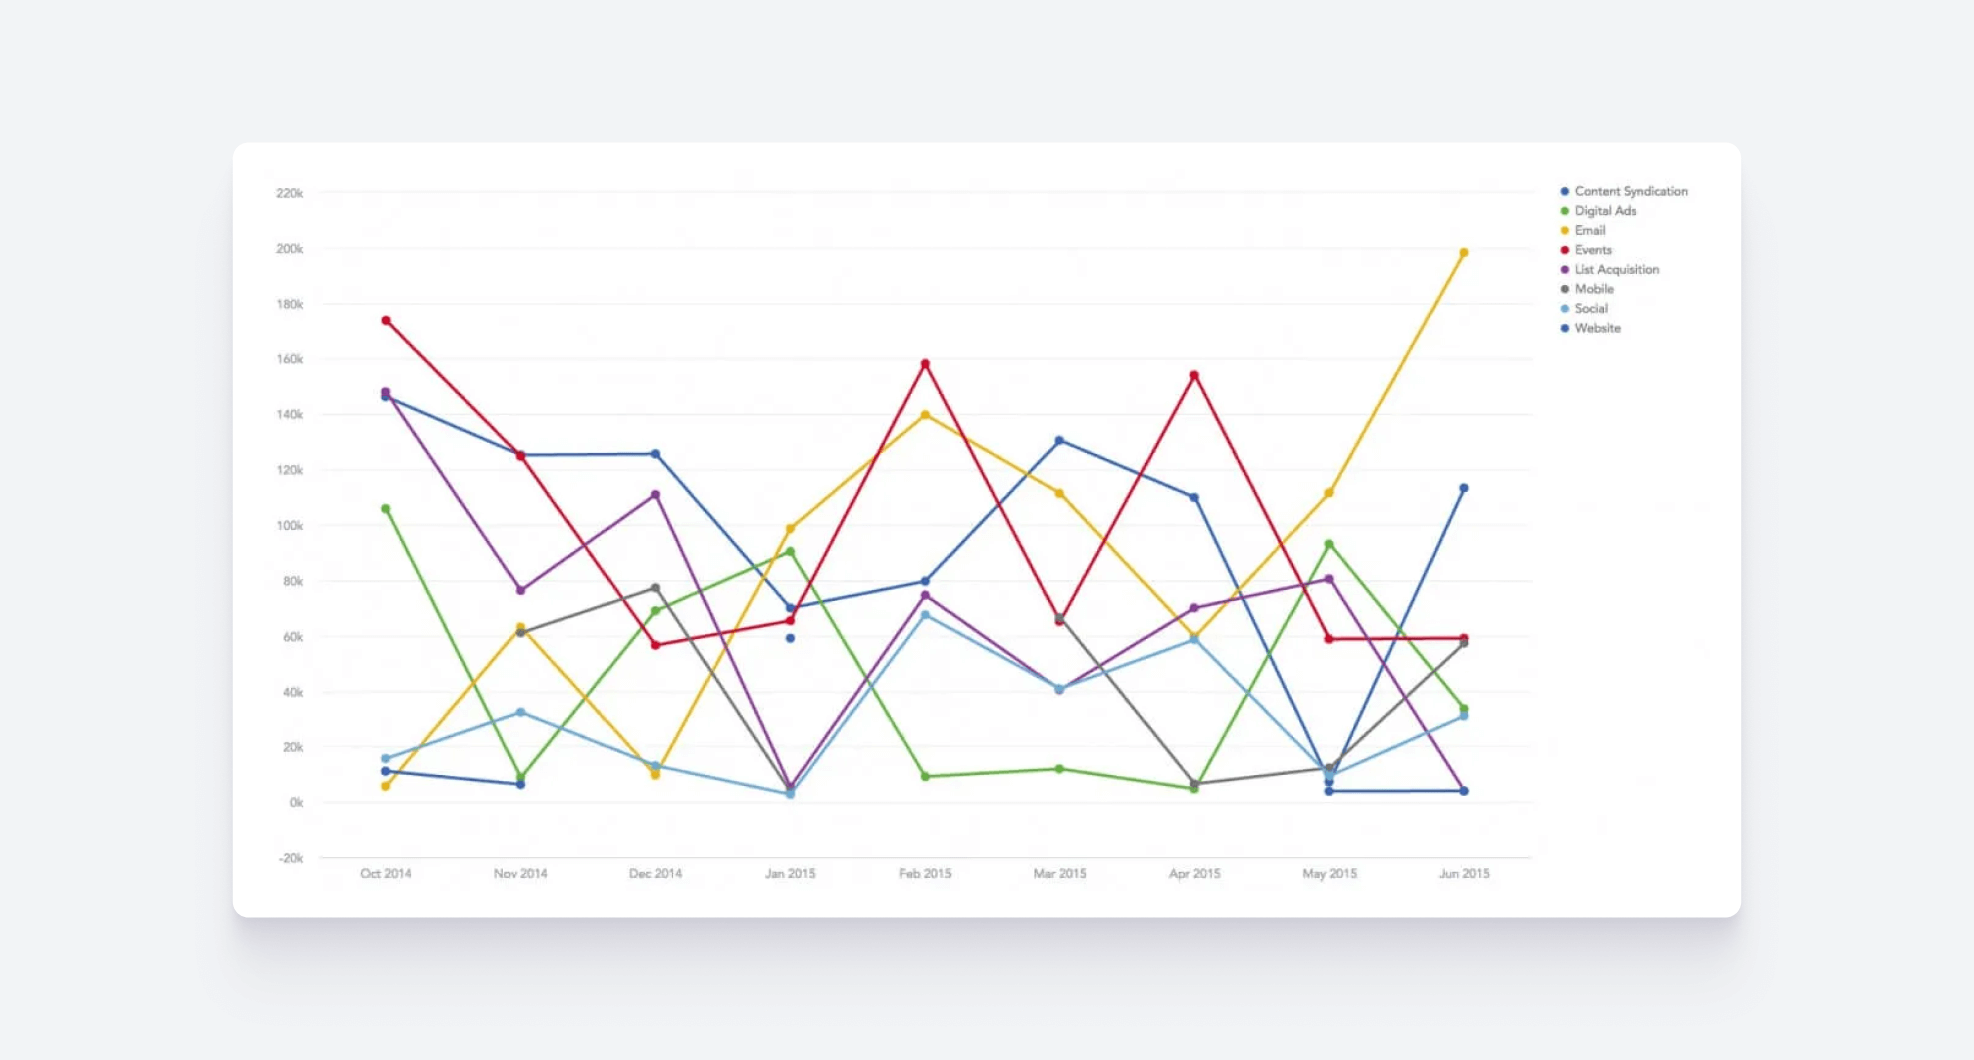

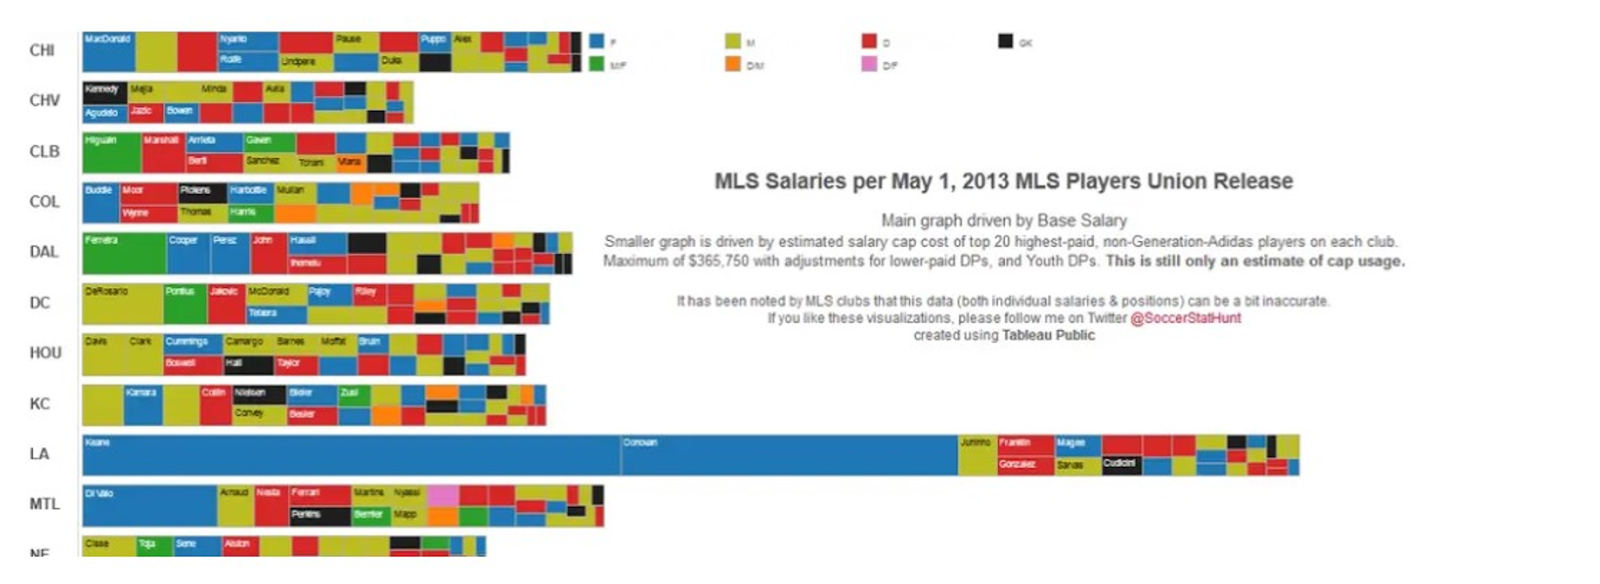

Why are these poor data visualizations?: The data is too clustered which makes it hard to read and understand. The data should be spread out instead fo grouped.